In [2]:
# pandas → 표 형태의 데이터 생성 및 분석
# numpy → 가상의 파티클 측정값 생성
# matplotlib → 시간에 따른 파티클 변화 시각화
# IsolationForest → 평소와 다른 비정상 파티클 데이터 탐지

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [3]:
# 실제 particle_data.csv가 없으므로 실습용 가상 데이터 생성
# 결과를 다시 실행해도 동일하게 나오도록 난수 고정

np.random.seed(42)

# 100일간의 측정 날짜 생성
dates = pd.date_range(
    start='2026-01-01',
    periods=100,
    freq='D'
)

# 평균 파티클 수 생성
# 정상적인 경우 약 20개 주변에서 변동한다고 가정
avg_particle = np.random.normal(
    loc=20,
    scale=3,
    size=100
)

# 최대 파티클 수는 평균 파티클보다 조금 높게 생성
max_particle = avg_particle + np.random.normal(
    loc=8,
    scale=2,
    size=100
)

# 세정 설비 3대를 사용한다고 가정
tool_id = np.random.choice(
    ['CLEANER_A', 'CLEANER_B', 'CLEANER_C'],
    size=100
)

# DataFrame 생성
df = pd.DataFrame({
    'DATE': dates,
    'TOOL_ID': tool_id,
    'AVG_PARTICLE': avg_particle,
    'MAX_PARTICLE': max_particle
})

df.head()

,DATE,TOOL_ID,AVG_PARTICLE,MAX_PARTICLE
0,2026-01-01,CLEANER_B,21.490142,26.659401
1,2026-01-02,CLEANER_B,19.585207,26.743916
2,2026-01-03,CLEANER_A,21.943066,29.257637
3,2026-01-04,CLEANER_A,24.569090,30.964535
4,2026-01-05,CLEANER_A,19.297540,26.974968


In [4]:
# 이상 탐지 실습을 위해 일부 날짜에 높은 파티클 값을 인위적으로 추가
# 실제 현장에서는 이런 값을 센서/검사 장비에서 측정하게 됨

anomaly_indices = [20, 50, 75]

df.loc[anomaly_indices, 'AVG_PARTICLE'] += [20, 25, 18]
df.loc[anomaly_indices, 'MAX_PARTICLE'] += [25, 30, 22]

# 생성된 데이터 확인
df.loc[anomaly_indices]

,DATE,TOOL_ID,AVG_PARTICLE,MAX_PARTICLE
20,2026-01-21,CLEANER_A,44.396946,58.979010
50,2026-02-20,CLEANER_A,45.972252,59.473238
75,2026-03-17,CLEANER_A,40.465708,54.120074


In [5]:
# 세정 전/후 파티클 수를 가상으로 생성
# 세정 후 파티클 수가 감소하면 정상적인 세정 효과로 볼 수 있음

df['PARTICLE_BEFORE'] = df['AVG_PARTICLE'] + np.random.normal(
    loc=10,
    scale=2,
    size=len(df)
)

df['PARTICLE_AFTER'] = df['AVG_PARTICLE']

# 파티클 변화량 계산
df['DELTA_PARTICLE'] = (
    df['PARTICLE_AFTER']
    - df['PARTICLE_BEFORE']
)

df[
    ['DATE',
     'PARTICLE_BEFORE',
     'PARTICLE_AFTER',
     'DELTA_PARTICLE']
].head()

,DATE,PARTICLE_BEFORE,PARTICLE_AFTER,DELTA_PARTICLE
0,2026-01-01,30.811370,21.490142,-9.321227
1,2026-01-02,27.954665,19.585207,-8.369458
2,2026-01-03,33.341250,21.943066,-11.398185
3,2026-01-04,35.768883,24.569090,-11.199793
4,2026-01-05,28.335044,19.297540,-9.037504


In [6]:
# 이상 탐지에 사용할 두 개의 파티클 변수 선택
# AVG_PARTICLE → 평균 파티클 수
# MAX_PARTICLE → 최대 파티클 수

X = df[
    ['AVG_PARTICLE', 'MAX_PARTICLE']
].values

print("분석 데이터 크기:", X.shape)

분석 데이터 크기: (100, 2)


In [7]:
# Isolation Forest 모델 생성
# n_estimators=200 → 200개의 트리를 이용해 이상 여부 판단
# contamination=0.05 → 전체 데이터의 약 5%를 이상치로 가정
# random_state=42 → 실행할 때마다 같은 결과가 나오도록 고정

clf = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

# 정상 데이터는 1
# 이상 데이터는 -1로 분류
df['anomaly_score'] = clf.fit_predict(X)

# -1인 데이터만 True로 표시
df['is_anomaly'] = (
    df['anomaly_score'] == -1
)

df[
    ['DATE',
     'AVG_PARTICLE',
     'MAX_PARTICLE',
     'anomaly_score',
     'is_anomaly']
].head()

,DATE,AVG_PARTICLE,MAX_PARTICLE,anomaly_score,is_anomaly
0,2026-01-01,21.490142,26.659401,1,False
1,2026-01-02,19.585207,26.743916,1,False
2,2026-01-03,21.943066,29.257637,1,False
3,2026-01-04,24.569090,30.964535,1,False
4,2026-01-05,19.297540,26.974968,1,False


In [8]:
# Isolation Forest가 이상으로 판단한 데이터만 추출

anomalies = df[df['is_anomaly']]

print("전체 데이터 수:", len(df))
print("탐지된 이상 데이터 수:", len(anomalies))

anomalies[
    ['DATE',
     'TOOL_ID',
     'AVG_PARTICLE',
     'MAX_PARTICLE']
]

전체 데이터 수: 100
탐지된 이상 데이터 수: 5


,DATE,TOOL_ID,AVG_PARTICLE,MAX_PARTICLE
6,2026-01-07,CLEANER_B,24.737638,36.510010
20,2026-01-21,CLEANER_A,44.396946,58.979010
50,2026-02-20,CLEANER_A,45.972252,59.473238
74,2026-03-16,CLEANER_C,12.140765,20.694146
75,2026-03-17,CLEANER_A,40.465708,54.120074


In [9]:
# AVG_PARTICLE의 평균과 표준편차 계산

particle_mean = df['AVG_PARTICLE'].mean()
particle_std = df['AVG_PARTICLE'].std()

# 평균 + 3 × 표준편차를 상한 관리선으로 설정
upper = particle_mean + 3 * particle_std

print(f"평균 Particle: {particle_mean:.2f}")
print(f"표준편차: {particle_std:.2f}")
print(f"3σ Upper Control Limit: {upper:.2f}")

평균 Particle: 20.32
표준편차: 4.92
3σ Upper Control Limit: 35.08


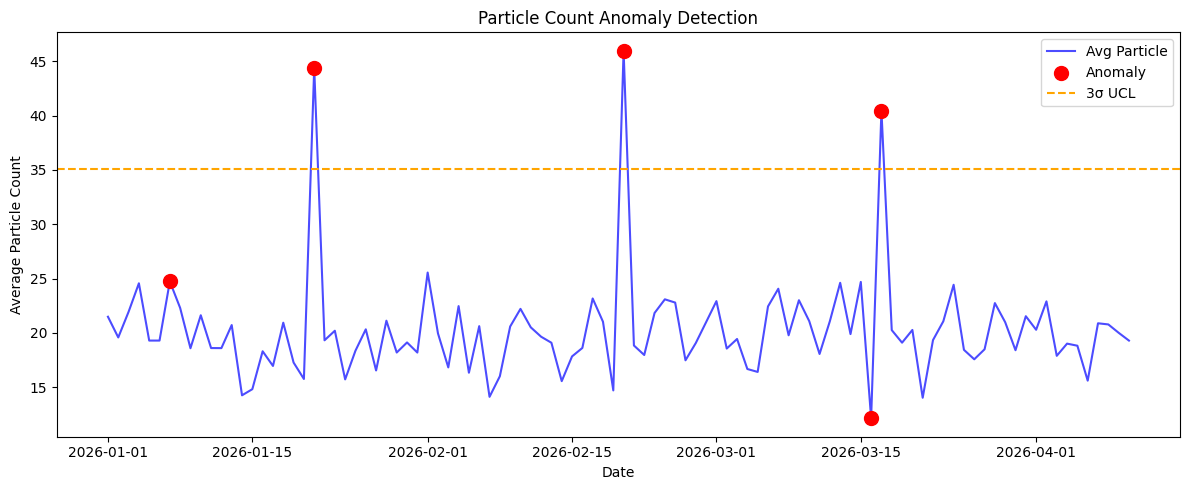

In [10]:
# 시간에 따른 평균 파티클 변화 시각화

fig, ax = plt.subplots(figsize=(12, 5))

# 전체 AVG_PARTICLE 추세
ax.plot(
    df['DATE'],
    df['AVG_PARTICLE'],
    'b-',
    alpha=0.7,
    label='Avg Particle'
)

# Isolation Forest가 탐지한 이상 데이터
anomalies = df[df['is_anomaly']]

ax.scatter(
    anomalies['DATE'],
    anomalies['AVG_PARTICLE'],
    color='red',
    s=100,
    zorder=5,
    label='Anomaly'
)

# 3σ 관리 상한선 표시
upper = (
    df['AVG_PARTICLE'].mean()
    + 3 * df['AVG_PARTICLE'].std()
)

ax.axhline(
    y=upper,
    color='orange',
    linestyle='--',
    label='3σ UCL'
)

ax.set_title('Particle Count Anomaly Detection')
ax.set_xlabel('Date')
ax.set_ylabel('Average Particle Count')
ax.legend()

plt.tight_layout()
plt.show()

In [11]:
# 이상이 발생한 날짜와 설비를 확인
# 실제 공정에서는 해당 날짜를 PM 일정, 약액 교체,
# 클린룸 점검 등의 이벤트 로그와 비교하여 원인을 추적

print("이상 탐지 날짜:")

print(
    anomalies[
        ['DATE', 'TOOL_ID', 'AVG_PARTICLE']
    ].to_string(index=False)
)

이상 탐지 날짜:
      DATE   TOOL_ID  AVG_PARTICLE
2026-01-07 CLEANER_B     24.737638
2026-01-21 CLEANER_A     44.396946
2026-02-20 CLEANER_A     45.972252
2026-03-16 CLEANER_C     12.140765
2026-03-17 CLEANER_A     40.465708
